# Regression Final Project - Medical Insurance dataset
**Author:** Jarred Gastreich 
**Date:** November, 25, 2025 
**Objective:** This project uses regression alalysis to determine insurance charges based on age, BMI and smoking status.


In [83]:
# Imports

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Section 1 Load and Inspect Data

In [84]:
# Load insurance dataset from data folder and verify
insurance = pd.read_csv(r"C:\Repos\ml-modules\notebooks\ml_regression_jarred\data\insurance.csv")
print(insurance.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [85]:
# 1. Check for missing values in every column
print("Missing Values per Column:")
print(insurance.isnull().sum())

print("\n" + "-"*30 + "\n")

# 2. Display summary statistics for numeric columns
print("Summary Statistics:")
print(insurance.describe())

# 3. Check data types of each column
print("\nData Types:")
print(insurance.dtypes)


Missing Values per Column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

------------------------------

Summary Statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


## Section 1 Relfection

The data has no missing values meaning every cell is complete for each feature. The statistics tell us that on average, each insured person has 1 child and is charged $13270, has a BMI of 30 and is around 39 years old.

# Section 2. Data Exploration and Prep

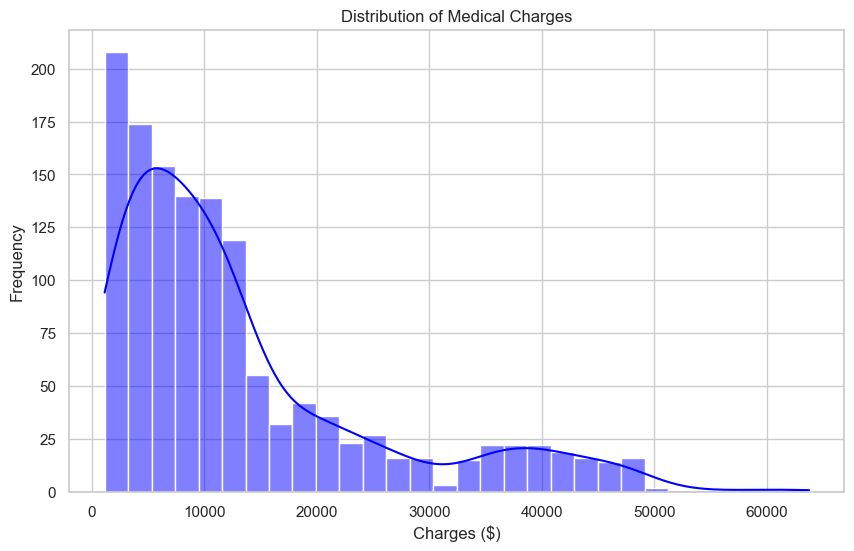

Skewness: 1.52


In [86]:
# Explore data patterns and distributions
# Set a clean visual style
sns.set(style="whitegrid")

# 1. Create the Histogram
plt.figure(figsize=(10, 6))
sns.histplot(insurance['charges'], kde=True, color='blue')
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.show()

# 2. Calculate the Skewness number
skew_value = insurance['charges'].skew()
print(f"Skewness: {skew_value:.2f}")

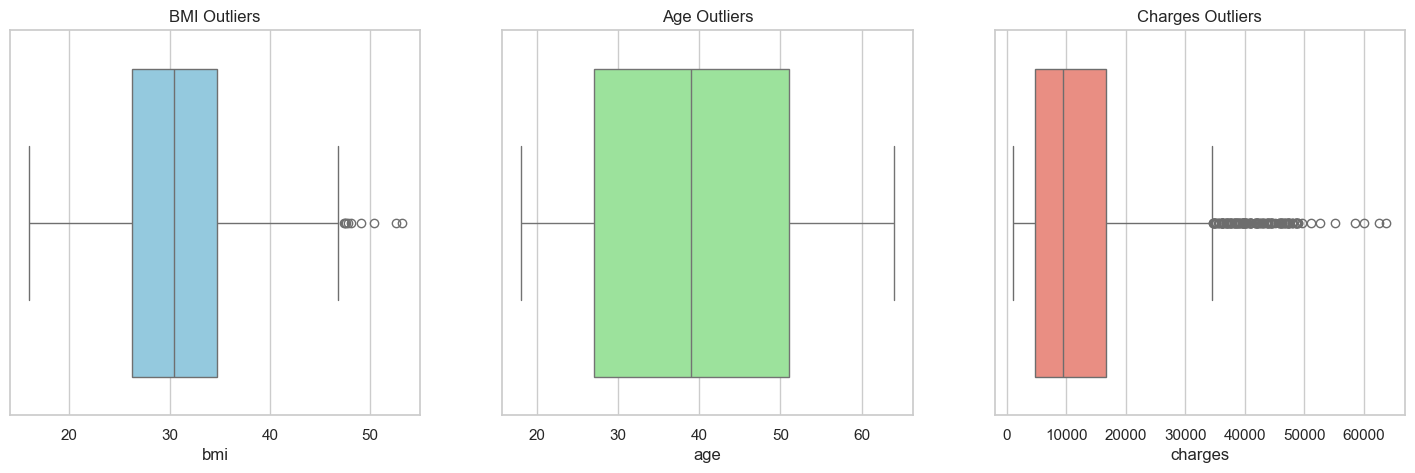

In [87]:
# Check Outliers

# Set up a grid of 3 plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot for BMI
sns.boxplot(ax=axes[0], x=insurance['bmi'], color='skyblue')
axes[0].set_title('BMI Outliers')

# Boxplot for Age
sns.boxplot(ax=axes[1], x=insurance['age'], color='lightgreen')
axes[1].set_title('Age Outliers')

# Boxplot for Charges
sns.boxplot(ax=axes[2], x=insurance['charges'], color='salmon')
axes[2].set_title('Charges Outliers')

plt.show()

In [88]:
# This creates the missing columns)
# We use drop_first=True to avoid the dummy variable trap (hides 'northeast')
insurance = pd.get_dummies(insurance, columns=['region'], drop_first=True)

# 2. VERIFY COLUMNS EXIST
# This print statement proves the columns are now there
print("Current Columns:", insurance.columns.tolist())

# ---------------------------------------------------------
# 3. NOW RUN YOUR CALCULATION
# ---------------------------------------------------------
region_cols = ['region_northwest', 'region_southeast', 'region_southwest']
region_counts = insurance[region_cols].sum()

print("\nCounts per engineered region:")
print(region_counts)

# Calculate implied northeast count
total_rows = len(insurance)
northeast_count = total_rows - region_counts.sum()

print(f"Implied count for region_northeast (Reference): {northeast_count}")

Current Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

Counts per engineered region:
region_northwest    325
region_southeast    364
region_southwest    325
dtype: int64
Implied count for region_northeast (Reference): 324


In [89]:
# List the columns you created
region_cols = ['region_northwest', 'region_southeast', 'region_southwest']

# Sum them up to get the frequency
region_counts = insurance[region_cols].sum()

print("Counts per engineered region:")
print(region_counts)

# Calculate total rows
total_rows = len(insurance)

# Calculate the implied count of the reference category (Northeast)
northeast_count = total_rows - region_counts.sum()

print(f"Implied count for region_northeast (Reference): {northeast_count}")

Counts per engineered region:
region_northwest    325
region_southeast    364
region_southwest    325
dtype: int64
Implied count for region_northeast (Reference): 324


In [90]:
# Section 2.2 Clean Data - Convert categorical Data to numerical format

# Convert sex column to numerical
insurance['sex'] = insurance['sex'].map({'male': 0, 'female': 1})   

# Convert smoker column to numerical
insurance['smoker'] = insurance['smoker'].map({'no': 0, 'yes': 1})

# Create the region_northeast column: 1 if all others are 0, else 0
insurance['region_northeast'] = (
    (insurance['region_northwest'] == 0) & 
    (insurance['region_southeast'] == 0) & 
    (insurance['region_southwest'] == 0)
).astype(int)

# Verify it exists now
print(insurance['region_northeast'].value_counts())



region_northeast
0    1014
1     324
Name: count, dtype: int64


In [91]:
# We assume BMI is a greater risk if smoking status is yes and will multiply the risk factor which is considered by some insurance companies.

# Create interaction term
insurance['bmi_smoker_interaction'] = insurance['bmi'] * insurance['smoker']

# Create a 'Obese' category (BMI > 30)
insurance['is_obese'] = (insurance['bmi'] >= 30).astype(int)

print("New features created.")
print(insurance[['bmi_smoker_interaction', 'is_obese']].head())

New features created.
   bmi_smoker_interaction  is_obese
0                    27.9         0
1                     0.0         1
2                     0.0         1
3                     0.0         0
4                     0.0         0


In [92]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Select columns to scale (we typically don't scale binary 0/1 columns)
cols_to_scale = ['age', 'bmi', 'children', 'bmi_smoker_interaction']

# Apply the scaling
insurance[cols_to_scale] = scaler.fit_transform(insurance[cols_to_scale])

# Check the results (Mean should be ~0, Std ~1)
insurance[cols_to_scale].describe()

,age,bmi,children,bmi_smoker_interaction
count,1.338000e+03,1.338000e+03,1.338000e+03,1.338000e+03
mean,-1.805565e-16,-2.124194e-16,-5.576008e-17,2.788004e-17
std,1.000374e+00,1.000374e+00,1.000374e+00,1.000374e+00
min,-1.509965e+00,-2.412011e+00,-9.086137e-01,-4.945163e-01
25%,-8.691547e-01,-7.164063e-01,-9.086137e-01,-4.945163e-01
50%,-1.474046e-02,-4.320880e-02,-7.876719e-02,-4.945163e-01
75%,8.396738e-01,6.611572e-01,7.510793e-01,-4.945163e-01
max,1.765289e+00,3.685522e+00,3.240619e+00,3.640230e+00


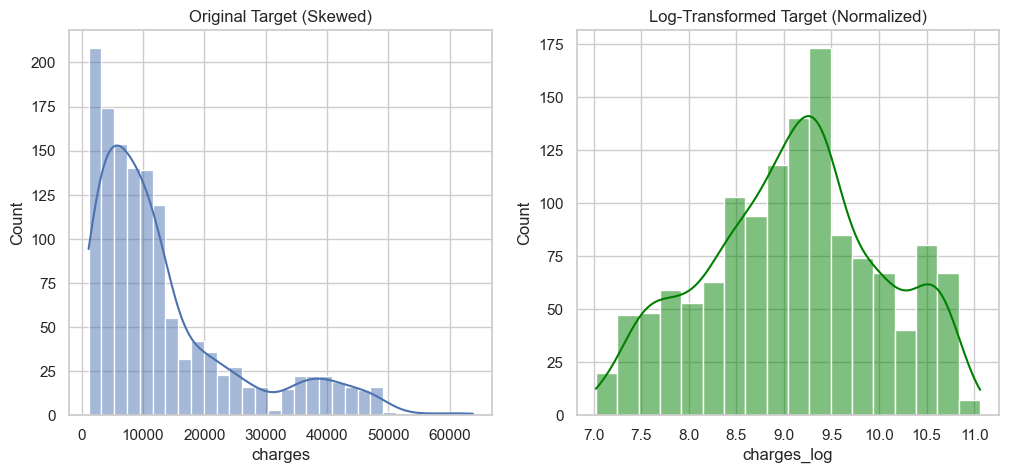

In [93]:
# Apply Log Transform to the target variable
# np.log1p calculates log(1 + x) to avoid errors with zero values
insurance['charges_log'] = np.log1p(insurance['charges'])

plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
sns.histplot(insurance['charges'], kde=True)
plt.title("Original Target (Skewed)")

# Log Transformed
plt.subplot(1, 2, 2)
sns.histplot(insurance['charges_log'], kde=True, color='green')
plt.title("Log-Transformed Target (Normalized)")

plt.show()

## Section 2 Reflection

Ideally sex should not be a big influence on insurance chanrge so we may not consider it. We did a combined interaction between BMI and smoker because those with a high BMI and smoking status of 1 will be more risky. Created a new feature for high BMI. We changed categorical data to numerical and found a missing feature for region_northeast.

# Section 3 Feature Selection and Justification

In [94]:
# 1. Define the Input Features (X)
# We select all the numeric/encoded columns we want the model to use.
# Note: We EXCLUDE the target ('charges') and the log-target ('charges_log') to prevent data leakage.
feature_cols = [
    'age', 
    'bmi', 
    'children', 
    'smoker', 
    'sex', 
    'bmi_smoker_interaction',
    'region_northwest', 
    'region_southeast', 
    'region_southwest'
]

X = insurance[feature_cols]

# 2. Define the Target Variable (y)
# We are predicting the raw dollar amount.
y = insurance['charges']

# 3. Verify the shapes
print(f"Feature Matrix (X) Shape: {X.shape}")  # Should be (1338, 9)
print(f"Target Vector (y) Shape:  {y.shape}")  # Should be (1338,)

# Preview X to make sure it looks correct (all numbers, no text)
X.head()

Feature Matrix (X) Shape: (1338, 9)
Target Vector (y) Shape:  (1338,)


,age,bmi,children,smoker,sex,bmi_smoker_interaction,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,1,1,1.699463,False,False,True
1,-1.509965,0.509621,-0.078767,0,0,-0.494516,False,True,False
2,-0.797954,0.383307,1.580926,0,0,-0.494516,False,True,False
3,-0.441948,-1.305531,-0.908614,0,0,-0.494516,True,False,False
4,-0.513149,-0.292556,-0.908614,0,0,-0.494516,True,False,False


## Section 3 Reflection

The target feature is charges because we want to predict insurance charges based on the payer's data. We will use most of the other features to make the prediction because we aren't sure if anything should be excluded at this point. Smoker should have a heavy influence, as well as age and children. I am including BMI though I am doubtful that insurance companies get this information when registering and determining a charge, we will see.

# Section 4 Train a Model (Linear Regression)

In [95]:
# 1. Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize the Model
model = LinearRegression()

# 3. Train the Model (Fit)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [96]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Generate Predictions on the Test Set
y_pred = model.predict(X_test)

# 2. Calculate Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error

# 3. Print Results
print("--- Model Performance ---")
print(f"R² Score: {r2:.4f} (The model explains {r2*100:.1f}% of the variance)")
print(f"MAE:      ${mae:,.2f} (Average error per prediction)")
print(f"RMSE:     ${rmse:,.2f} (Penalty for large errors)")

--- Model Performance ---
R² Score: 0.8653 (The model explains 86.5% of the variance)
MAE:      $2,756.90 (Average error per prediction)
RMSE:     $4,573.81 (Penalty for large errors)


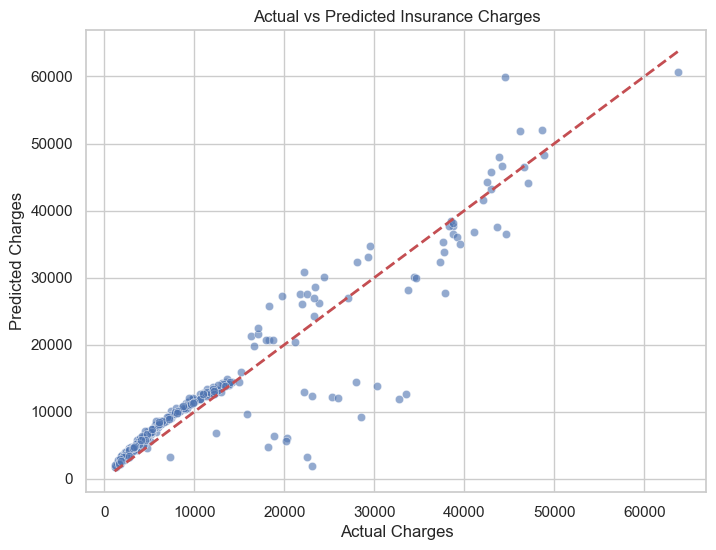

In [97]:

plt.figure(figsize=(8, 6))

# Scatter plot of Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# A red line representing perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.show()

## Section 4 Reflection

This is a strong performance because the R^2 is 0.865 which is good for human data. It's likely this would be lower without the feature engineering for bmi_smoker_interaction. On average, the guess is off by around $2700 (MAE(2756)) which is respectable given the range is from 1-60k. However the RMSE is 4573 which tells us that when the model misses, it misses by a large margin which might be because of the BMI outliers.

# Section 5 Improve the model or Try Alternates (pipelines)

In [98]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# 1. Define the Pipelines
# Pipeline 1: Linear Regression with Scaling
pipe_linear = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # Handles potential missing values
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Pipeline 2: Polynomial Regression (Degree 3)
pipe_poly3 = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('poly', PolynomialFeatures(degree=3)),      # Creates interaction terms
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# 2. Helper function to train and evaluate
results = []

def evaluate_pipeline(name, pipeline, X_tr, y_tr, X_te, y_te):
    # Train
    pipeline.fit(X_tr, y_tr)
    
    # Predict
    y_pred = pipeline.predict(X_te)
    
    # Calculate Metrics
    r2 = r2_score(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    
    # Store results
    results.append({
        'Model': name,
        'R2 Score': r2,
        'MAE': mae,
        'RMSE': rmse
    })

# 3. Run the evaluations
# (We use the X_train/y_train from previous steps)

# Evaluate Pipeline 1
evaluate_pipeline("Linear Regression (Scaled)", pipe_linear, X_train, y_train, X_test, y_test)

# Evaluate Pipeline 2
evaluate_pipeline("Polynomial Reg (Degree 3)", pipe_poly3, X_train, y_train, X_test, y_test)

# 4. Create Comparison Table
results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)

# Formatting for cleaner reading
print(results_df.sort_values(by='R2 Score', ascending=False))

                            R2 Score          MAE         RMSE
Model                                                         
Linear Regression (Scaled)   0.86525  2756.898660  4573.807686
Polynomial Reg (Degree 3)    0.79238  3147.162758  5677.386234


## Section 5 Reflection

In this case, simpler was better. The polynomial regression (degree 3) performed worse on every single metric and overfitted. This is likely because with the degree 3 it looked at every possible combination of 3 variables that likely created junk features. I will discard the Degree 3 model.

# Section 6 Final Thoughts

The goal of this project was to predict the payer's insurance charge based on demographic and health data. I developed a linear regression model that got a R^2 score of 0.856 which I considered good.

In the feature engineering stage, we determiend that there would be a smoke effect based on my previous experience when signing up for health insurance.

Insurance agencies in this dataset did consider BMI for charge and their charge calculation was heavily determined by if the payer smoked and had a high BMI. The bmi_smoker_interaction feature showed that the risk of high BMI is not linear, it compounds drastically for smokers.

When testing another model (degree 3), I learned that simpler was better in this case because it overfitted.

Some challenges faced were when creating new features and running individual code cells vs running the whole noteobok especially when one-hot encoding for region. Research was important early on to determine the benefit of engineering the smoker and bmi features together. 

If I had more time, I would like to train the model on the log-transformed charges because the new feature might drastically reduce error for high-cost patients. I would also like to try non-linear tree-based models like Random Forest.